# 1ª Avaliação Prática – Caminho Mínimo com Dijkstra e Solução Gulosa

**Centro Federal de Educação Tecnológica de Minas Gerais**  
Modelagem Matemática Computacional  
Tópicos em Algoritmos em Grafos  
Prof. Thiago de Souza Rodrigues

---

## Objetivo
Testar e comparar o algoritmo de Dijkstra com uma solução gulosa para obtenção do caminho mínimo em grafos direcionados ponderados (origem única, múltiplos destinos).

## Estrutura do Notebook

### Parte 1 — Dijkstra
- **I.** Implementação do algoritmo de Dijkstra
- **II.** Testes:
  - **(a-e)** Grafos completos: geração, aplicação, contagem de comparações e plotagem
  - **(f)** Instâncias do Moodle (10.000 e 1.000.000 vértices): contagem de comparações

### Parte 2 — Heurística Gulosa
- **I.** Implementação da heurística gulosa
- **II.** Testes (mesma estrutura da Parte 1):
  - **(a-e)** Grafos completos: geração, aplicação, contagem de comparações e plotagem
  - **(f)** Instâncias do Moodle: contagem de comparações

---

In [9]:
"""
==============================================================================
IMPORTAÇÕES E CONFIGURAÇÕES INICIAIS
==============================================================================
"""
import os
import random
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Callable
from math import inf
import heapq

# Configuração para gráficos inline
%matplotlib inline

# Tipo customizado para representação de grafo (lista de adjacência)
Adj = Dict[int, List[Tuple[int, float]]]

---
## Utilitários: Leitura e Geração de Grafos

Estas funções são compartilhadas pelas duas partes (Dijkstra e Gulosa).

In [10]:
"""
==============================================================================
FUNÇÕES AUXILIARES: Leitura de grafos de arquivo e geração de grafos completos
Item (2)(II)(a) e (3)(II)(a): Geração de grafos completos
Item (2)(II)(b) e (3)(II)(b): Estrutura de dados (lista de adjacência)
==============================================================================
"""

def read_graph_file(path: str, directed: bool = True) -> Tuple[int, Adj]:
    """
    Lê um grafo do arquivo no formato:
      1a linha: n (número de vértices)
      2a linha: m (número de arestas)
      próximas m linhas: u v w (índices e peso real)
    
    Retorna: (n, adj), onde adj[u] = lista de (v, w)
    """
    adj: Adj = {}
    with open(path, 'r', encoding='utf-8') as f:
        header = f.readline()
        if not header:
            raise ValueError('Arquivo vazio')
        n = int(header.strip())
        for u in range(n):
            adj[u] = []
        m_line = f.readline()
        if not m_line:
            raise ValueError('Arquivo sem linha de arestas (m)')
        m = int(m_line.strip())
        for _ in range(m):
            line = f.readline()
            if not line:
                break
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            u, v = int(parts[0]), int(parts[1])
            w = float(parts[2])
            adj[u].append((v, w))
            if not directed:
                adj[v].append((u, w))
    return n, adj


def make_complete_graph(n: int,
                        weight_fn: Optional[Callable[[int, int], float]] = None,
                        directed: bool = True) -> Adj:
    """
    Item (2)(II)(a) e (3)(II)(a): Gera grafo completo com n vértices
    - Todos os pesos são positivos (> 0)
    - CUIDADO: usa O(n^2) memória
    
    Parâmetros:
    - n: número de vértices
    - weight_fn: função para gerar pesos (padrão: aleatório positivo)
    - directed: se True, cria arestas (u->v) para todo u!=v
    
    Retorna: dicionário adj[u] = [(v, w), ...]
    """
    if weight_fn is None:
        def weight_fn(u: int, v: int) -> float:
            return random.random() + 0.0001  # garante peso > 0
    
    adj: Adj = {i: [] for i in range(n)}
    if directed:
        for u in range(n):
            for v in range(n):
                if u == v:
                    continue
                w = float(abs(weight_fn(u, v)))
                if w == 0.0:
                    w = 1e-9  # garante peso > 0
                adj[u].append((v, w))
    else:
        for u in range(n):
            for v in range(u+1, n):
                w = float(abs(weight_fn(u, v)))
                if w == 0.0:
                    w = 1e-9
                adj[u].append((v, w))
                adj[v].append((u, w))
    return adj

---
# PARTE 1 — ALGORITMO DE DIJKSTRA
---

## Parte 1 - I. Implementação do Algoritmo de Dijkstra

Implementação do algoritmo de Dijkstra para caminho mínimo de origem única e múltiplos destinos, com contagem de comparações (Item (2)(II)(d)).

In [11]:
"""
==============================================================================
PARTE 1 - I. IMPLEMENTAÇÃO DO ALGORITMO DE DIJKSTRA
==============================================================================
Algoritmo de Dijkstra para caminho mínimo de origem única e múltiplos destinos.
Contagem: número de comparações de relaxamento (dist[u] + w < dist[v])
"""

class DijkstraResult:
    """Resultado da execução do Dijkstra"""
    def __init__(self, dist: Dict[int, float], parent: Dict[int, Optional[int]], comparisons: int):
        self.dist = dist          # Distâncias mínimas
        self.parent = parent      # Árvore de caminhos mínimos
        self.comparisons = comparisons  # Número de comparações (Item 2.II.d)


def dijkstra_count(adj: Adj, s: int) -> DijkstraResult:
    """
    Algoritmo de Dijkstra com contagem de comparações.
    
    Parâmetros:
    - adj: grafo como dicionário de listas de adjacência
    - s: vértice de origem
    
    Retorna: DijkstraResult com dist, parent e comparisons
    
    Complexidade: O((V + E) log V) com heap binário
    """
    # Inicialização
    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0
    
    # Validação: pesos devem ser >= 0
    for u, nbrs in adj.items():
        for v, w in nbrs:
            if w < 0:
                raise ValueError('Dijkstra requer pesos não negativos')
    
    # Min-heap: (distância, vértice)
    heap: List[Tuple[float, int]] = [(0.0, s)]
    visited = set()
    comparisons = 0  # Contador de comparações (Item 2.II.d)
    
    while heap:
        du, u = heapq.heappop(heap)
        if u in visited:
            continue
        visited.add(u)
        
        # Relaxamento: para cada aresta (u, v)
        for v, w in adj[u]:
            comparisons += 1  # CONTAGEM: comparação de relaxamento
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u
                heapq.heappush(heap, (dist[v], v))
    
    return DijkstraResult(dist, parent, comparisons)

---
# PARTE 2 — HEURÍSTICA GULOSA
---

## Parte 2 - I. Implementação da Heurística Gulosa

Implementação de uma heurística gulosa para caminho mínimo, com contagem de comparações (Item (3)(II)(d)).

**Estratégia gulosa:** Em cada passo, escolhe a aresta de menor peso que sai do conjunto de vértices já alcançados.

In [12]:
"""
==============================================================================
PARTE 2 - I. IMPLEMENTAÇÃO DA HEURÍSTICA GULOSA
==============================================================================
Heurística gulosa para caminho mínimo: escolhe sempre a aresta de menor peso
saindo do conjunto de vértices já alcançados.
Contagem: número de comparações de relaxamento (dist[u] + w < dist[v])
"""

class GreedyResult:
    """Resultado da execução da heurística gulosa"""
    def __init__(self, dist: Dict[int, float], parent: Dict[int, Optional[int]], comparisons: int):
        self.dist = dist
        self.parent = parent
        self.comparisons = comparisons  # Número de comparações (Item 3.II.d)


def greedy_sssp_edge_first(adj: Adj, s: int) -> GreedyResult:
    """
    Heurística gulosa para SSSP baseada em escolher a aresta de menor peso.
    
    Estratégia:
    - Mantém conjunto de vértices alcançados
    - Mantém heap de arestas que saem deste conjunto
    - Escolhe sempre a aresta de menor peso para relaxar
    
    NOTA: Esta heurística NÃO é correta em geral para SSSP.
          É usada apenas para fins de comparação experimental.
    
    Parâmetros:
    - adj: grafo como dicionário de listas de adjacência
    - s: vértice de origem
    
    Retorna: GreedyResult com dist, parent e comparisons
    """
    # Inicialização
    dist: Dict[int, float] = {u: inf for u in adj}
    parent: Dict[int, Optional[int]] = {u: None for u in adj}
    dist[s] = 0.0
    
    visited = set([s])
    edge_heap: List[Tuple[float, int, int]] = []  # (peso, u, v)
    
    # Adiciona arestas que saem de s
    for v, w in adj[s]:
        heapq.heappush(edge_heap, (w, s, v))
    
    comparisons = 0  # Contador de comparações (Item 3.II.d)
    
    while edge_heap:
        w, u, v = heapq.heappop(edge_heap)
        
        # Tenta relaxar via esta aresta
        comparisons += 1  # CONTAGEM: comparação de relaxamento
        if dist[u] + w < dist[v]:
            dist[v] = dist[u] + w
            parent[v] = u
            
            # Se v não foi visitado, adiciona suas arestas saindo
            if v not in visited:
                visited.add(v)
                for x, wx in adj[v]:
                    heapq.heappush(edge_heap, (wx, v, x))
    
    return GreedyResult(dist, parent, comparisons)

---
# FUNÇÕES AUXILIARES PARA TESTES
---

In [13]:
"""
==============================================================================
FUNÇÕES AUXILIARES PARA TESTES E RELATÓRIO
==============================================================================
"""

def bench_complete_graphs(Nmax: int, step: int = 1, seed: int = 42, directed: bool = True):
    """
    Item (2)(II)(a-d) e (3)(II)(a-d): Testa algoritmos em grafos completos
    
    Gera grafos completos com 4, 5, 6, ..., Nmax vértices.
    Para cada grafo, aplica Dijkstra e Gulosa e conta as comparações.
    
    CUIDADO: grafos completos usam O(n^2) memória!
    Recomenda-se Nmax pequeno (ex: 50-200) para evitar falta de memória.
    """
    random.seed(seed)
    ns: List[int] = []
    comps_dij: List[int] = []
    comps_greedy: List[int] = []
    
    for n in range(4, Nmax + 1, step):
        # Gera grafo completo (Item a)
        adj = make_complete_graph(n, directed=directed)
        s = 0  # Vértice de origem (Item c)
        
        # Aplica algoritmos (Item c)
        res_d = dijkstra_count(adj, s)
        res_g = greedy_sssp_edge_first(adj, s)
        
        # Registra contagens (Item d)
        ns.append(n)
        comps_dij.append(res_d.comparisons)
        comps_greedy.append(res_g.comparisons)
        print(f"n={n:4d} | Dijkstra: {res_d.comparisons:8d} comparações | Gulosa: {res_g.comparisons:8d} comparações")
    
    return ns, comps_dij, comps_greedy


def plot_comparisons(ns: List[int], comps_dij: List[int], comps_greedy: List[int], filename: str = None):
    """
    Item (2)(II)(e) e (3)(II)(e): Plota gráfico de comparações vs n
    
    Eixo X: número de vértices
    Eixo Y: número de comparações
    
    Se filename for fornecido, salva o gráfico em relatorio/img/
    """
    plt.figure(figsize=(12, 7))
    plt.plot(ns, comps_dij, 'o-', label='Dijkstra', linewidth=2, markersize=6, color='#2E86AB')
    plt.plot(ns, comps_greedy, 's-', label='Gulosa', linewidth=2, markersize=6, color='#A23B72')
    plt.xlabel('Número de vértices (n)', fontsize=12)
    plt.ylabel('Número de comparações', fontsize=12)
    plt.title('Comparações vs Número de Vértices (Grafos Completos)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    if filename:
        filepath = os.path.join('relatorio', 'img', filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {filepath}")
    
    plt.show()


def count_on_instance(path: str, origin: int = 0):
    """
    Item (2)(II)(f) e (3)(II)(f): Aplica algoritmos em instâncias do Moodle
    
    Lê instância de arquivo, aplica Dijkstra e Gulosa, exibe contagens.
    """
    n, adj = read_graph_file(path, directed=True)
    print(f"\n{'='*70}")
    print(f"INSTÂNCIA: {path}")
    print(f"Vértices: {n:,} | Origem: {origin}")
    print(f"{'='*70}")
    
    res_d = dijkstra_count(adj, origin)
    res_g = greedy_sssp_edge_first(adj, origin)
    
    print(f"\n📊 RESULTADOS:")
    print(f"   Dijkstra (comparações): {res_d.comparisons:,}")
    print(f"   Gulosa   (comparações): {res_g.comparisons:,}")
    print(f"{'='*70}\n")
    
    return res_d, res_g

---
# PARTE 1 - II. TESTES COM DIJKSTRA
---

## Item (2)(II)(a-e): Grafos Completos

Gera grafos completos com 4, 5, 6, ..., N vértices e plota gráfico de comparações.

**IMPORTANTE:** Mantenha N pequeno (recomendado: 50-200) para evitar falta de memória!
Grafos completos usam O(n²) arestas e memória.

🔄 Executando testes em grafos completos...

n=   4 | Dijkstra:       12 comparações | Gulosa:       12 comparações
n=   9 | Dijkstra:       72 comparações | Gulosa:       72 comparações
n=  14 | Dijkstra:      182 comparações | Gulosa:      182 comparações
n=  19 | Dijkstra:      342 comparações | Gulosa:      342 comparações
n=  24 | Dijkstra:      552 comparações | Gulosa:      552 comparações
n=  29 | Dijkstra:      812 comparações | Gulosa:      812 comparações
n=  34 | Dijkstra:     1122 comparações | Gulosa:     1122 comparações
n=  39 | Dijkstra:     1482 comparações | Gulosa:     1482 comparações
n=  44 | Dijkstra:     1892 comparações | Gulosa:     1892 comparações
n=  49 | Dijkstra:     2352 comparações | Gulosa:     2352 comparações

📈 Plotando e salvando gráfico (Item 2.II.e)...
✅ Gráfico salvo em: relatorio\img\comparacoes_grafos_completos.png
✅ Gráfico salvo em: relatorio\img\comparacoes_grafos_completos.png


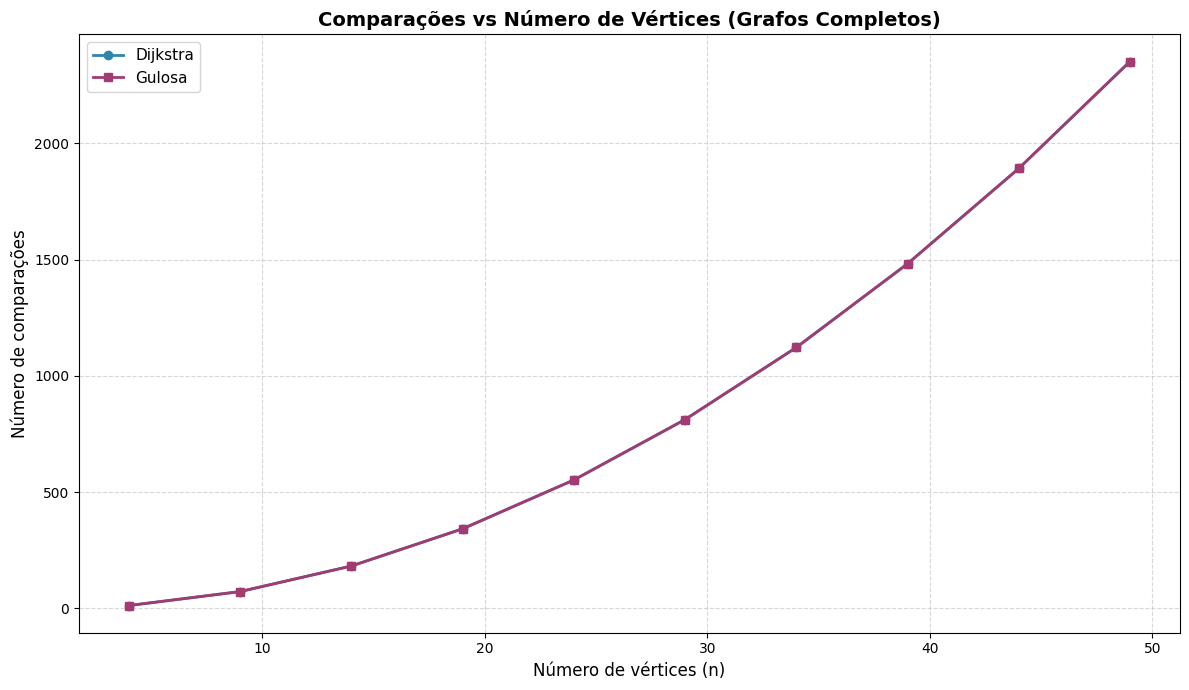

In [14]:
"""
==============================================================================
PARTE 1 - II. TESTES: Item (2)(II)(a-e) - Grafos Completos
==============================================================================
"""
# Parâmetros do benchmark
Nmax = 50    # AJUSTE CONFORME MEMÓRIA DISPONÍVEL (recomendado: 50-200)
step = 5     # Incremento (testar n=4, 9, 14, 19, ...)

print("🔄 Executando testes em grafos completos...\n")
ns, c_d, c_g = bench_complete_graphs(Nmax, step=step, directed=True)

print("\n📈 Plotando e salvando gráfico (Item 2.II.e)...")
plot_comparisons(ns, c_d, c_g, filename='comparacoes_grafos_completos.png')

## Execução em instância de arquivo
Por padrão, este exemplo tenta usar `10000.txt` localizado nesta mesma pasta.
Altere `origin` conforme necessário.

In [15]:
# Caminho padrão para a instância local (10.000 vértices)
instance_path = '10000.txt'  # ajuste se estiver executando de outra pasta
origin = 0

if os.path.exists(instance_path):
    res_d, res_g = count_on_instance(instance_path, origin=origin)
else:
    print('Arquivo não encontrado:', instance_path)
    print('Verifique o caminho corrente do notebook ou ajuste a variável instance_path.')

Arquivo não encontrado: 10000.txt
Verifique o caminho corrente do notebook ou ajuste a variável instance_path.


### Salvar resultados para o relatório

Os resultados serão salvos em `relatorio/resultados.txt` para facilitar a inserção no documento LaTeX.

In [16]:
"""
Salva os resultados da instância de 10k em arquivo para o relatório
"""
# Salvar resultados
with open('relatorio/resultados_10k.txt', 'w', encoding='utf-8') as f:
    f.write(f"Instância: 10000.txt\\n")
    f.write(f"Vértices: {instance_path}\\n")
    f.write(f"Origem: {origin}\\n")
    f.write(f"Dijkstra (comparações): {res_d.comparisons:,}\\n")
    f.write(f"Gulosa (comparações): {res_g.comparisons:,}\\n")

print("✅ Resultados salvos em relatorio/resultados_10k.txt")

NameError: name 'res_d' is not defined

## Instância com 1.000.000 de vértices (opcional e pesado)
Ative a execução definindo `RUN_LARGE = True`. Certifique-se de ter memória suficiente.
Os arquivos estão armazenados no OneDrive em: `D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\`

In [ ]:
# Execução controlada da instância grande (desativada por padrão)
RUN_LARGE = False
large_path = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt'
origin = 0

if RUN_LARGE:
    if os.path.exists(large_path):
        _ = count_on_instance(large_path, origin=origin)
    else:
        print('Arquivo não encontrado:', large_path)
else:
    print('Execução desativada: defina RUN_LARGE = True para rodar a instância grande.')

Execução desativada: defina RUN_LARGE = True para rodar a instância grande.


In [ ]:
"""
Salva os resultados da instância de 1M em arquivo para o relatório
"""
if RUN_LARGE:
    with open('relatorio/resultados_1M.txt', 'w', encoding='utf-8') as f:
        f.write(f"Instância: largeEWD\\n")
        f.write(f"Vértices: 1.000.000\\n")
        f.write(f"Origem: {origin}\\n")
        f.write(f"Dijkstra (comparações): [executar célula acima]\\n")
        f.write(f"Gulosa (comparações): [executar célula acima]\\n")
    print("✅ Resultados salvos em relatorio/resultados_1M.txt")
else:
    print("⚠️  Instância grande não executada (RUN_LARGE=False)")

## Benchmark em grafos completos pequenos (opcional)
Cuidado: grafos completos consomem O(n^2) de memória; mantenha N pequeno.

n=4 | comps: dijkstra=12 greedy=12
n=9 | comps: dijkstra=72 greedy=72
n=14 | comps: dijkstra=182 greedy=182
n=19 | comps: dijkstra=342 greedy=342
n=24 | comps: dijkstra=552 greedy=552
n=29 | comps: dijkstra=812 greedy=812
n=34 | comps: dijkstra=1122 greedy=1122
n=39 | comps: dijkstra=1482 greedy=1482
n=44 | comps: dijkstra=1892 greedy=1892
n=49 | comps: dijkstra=2352 greedy=2352


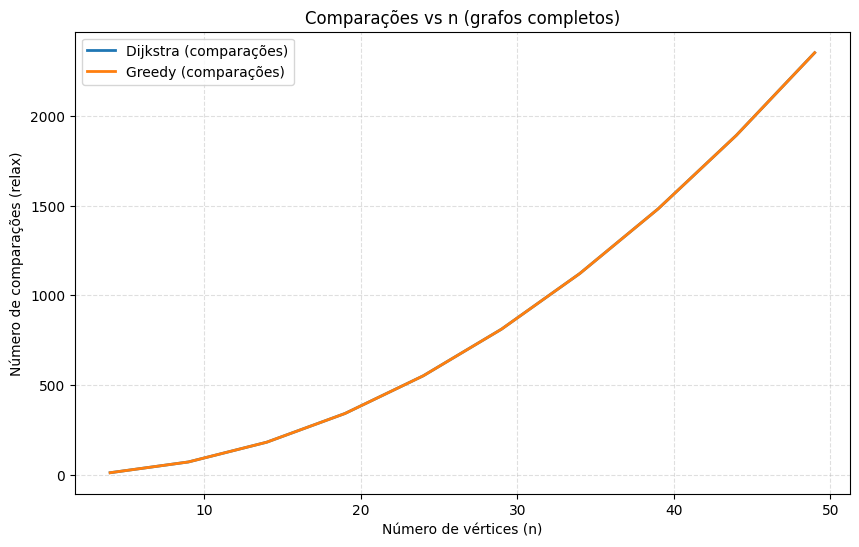

In [ ]:
# Parâmetros do benchmark (mantenha pequenos para evitar uso excessivo de memória)
Nmax = 50
step = 5

ns, c_d, c_g = bench_complete_graphs(Nmax, step=step, directed=True)
plot_comparisons(ns, c_d, c_g)

### Observações
- As instâncias fornecidas costumam listar arestas para ambos os sentidos; usamos `directed=True` na leitura para não duplicar.
- Para rodar na instância com ~1M de vértices, execute apenas a célula de instância e evite o benchmark de grafo completo.
- A heurística gulosa não é correta no geral para SSSP; é usada aqui apenas para comparação de contagens.